# SparkML Linear Regression — Realized Volatility Prediction

Trains Ridge and Lasso regression models on the 1-second MBO feature table to predict `rv_next_60` and `rv_next_300`.

- **Local**: reads Parquet from `~/Downloads/mbo_features_table`, local Spark session
- **Colab / EMR**: reads from S3, connects via Spark Connect on port 15002

Run **EDA_basic.ipynb** and **EDA_advanced.ipynb** first.

**Reference**: Bucci, A. (2021). Realized Volatility Forecasting with Neural Networks. *Journal of Financial Econometrics*. https://doi.org/10.1080/1350486X.2021.1967767

## 0. Install & Imports

In [1]:
import subprocess
import sys

try:
    from google.colab import drive
    IN_COLAB = True
    subprocess.run([sys.executable, '-m', 'pip', 'uninstall', '-y',
                    'dataproc-spark-connect', 'pyspark'], check=False)
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                    'pyspark==3.5.6', 'mlflow'], check=True)
except ImportError:
    IN_COLAB = False
    try:
        import mlflow
    except ImportError:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'mlflow'], check=True)

import pyspark
print(f'Colab   : {IN_COLAB}')
print(f'PySpark : {pyspark.__version__}')

/Users/nandhusriram/PycharmProjects/CIS5450/cis-5450-project/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Colab   : False
PySpark : 4.1.1


In [2]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.types import DoubleType

from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

import mlflow
import mlflow.spark
import mlflow.sklearn
from sklearn.linear_model import Ridge, Lasso

# MLflow tracking — shared db location
#MLFLOW_DB_PATH = os.path.expanduser('~/mlflow-db')
#os.makedirs(MLFLOW_DB_PATH, exist_ok=True)
#mlflow.set_tracking_uri(f'sqlite:///{MLFLOW_DB_PATH}/mlflow.db')
#print(f'MLflow tracking URI : {mlflow.get_tracking_uri()}')
#print(f'MLflow UI           : mlflow ui --backend-store-uri sqlite:///{MLFLOW_DB_PATH}/mlflow.db')

# MLflow tracking — shared EC2 server
# MLFLOW_DB_PATH = os.path.expanduser('~/mlflow-db')
# os.makedirs(MLFLOW_DB_PATH, exist_ok=True)
# mlflow.set_tracking_uri(f'sqlite:///{MLFLOW_DB_PATH}/mlflow.db')
mlflow.set_tracking_uri("http://52.204.56.137:5000")
print(f'MLflow tracking URI : {mlflow.get_tracking_uri()}')
print(f'MLflow UI           : http://localhost:5000')

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

MLflow tracking URI : http://52.204.56.137:5000
MLflow UI           : http://localhost:5000


In [20]:
!curl -s https://checkip.amazonaws.com

75.23.249.179


## 1. Environment & Spark Session

In [3]:
from getpass import getpass

BUCKET     = 'cis5450-mbo-project-final'
REGION     = 'us-east-1'
EMR_HOST   = 'ec2-54-242-244-39.compute-1.amazonaws.com'
MLFLOW_URI = 'http://52.204.56.137:5000'

mlflow.set_tracking_uri(MLFLOW_URI)

if IN_COLAB:
    os.environ['AWS_ACCESS_KEY_ID']     = getpass('AWS_ACCESS_KEY_ID: ').strip()
    os.environ['AWS_SECRET_ACCESS_KEY'] = getpass('AWS_SECRET_ACCESS_KEY: ').strip()
    os.environ['AWS_SESSION_TOKEN']     = getpass('AWS_SESSION_TOKEN: ').strip()
    os.environ['AWS_DEFAULT_REGION']    = REGION
else:
    # Local: use the 'upenn' profile from ~/.aws/credentials
    os.environ['AWS_PROFILE']         = 'upenn'
    os.environ['AWS_DEFAULT_REGION']  = REGION

DATA_PATH = f's3://{BUCKET}/processed_data/mbo_features_table'

print(f'Environment : {"Google Colab" if IN_COLAB else "Local"}')
print(f'EMR Host    : {EMR_HOST}')
print(f'MLflow URI  : {MLFLOW_URI}')
print(f'Data path   : {DATA_PATH}')


Environment : Local
EMR Host    : ec2-54-242-244-39.compute-1.amazonaws.com
MLflow URI  : http://52.204.56.137:5000
Data path   : s3://cis5450-mbo-project-final/processed_data/mbo_features_table


In [4]:
# Always connect to EMR ,Spark does the heavy lifting on S3 data
spark = SparkSession.builder \
    .appName('RV_LinearRegression') \
    .remote(f'sc://{EMR_HOST}:15002') \
    .getOrCreate()

spark.conf.set('spark.sql.session.timeZone', 'UTC')
print(f'Spark version : {spark.version}')
print(f'Connected to  : {EMR_HOST}')


Spark version : 3.5.6-amzn-1
Connected to  : ec2-54-242-244-39.compute-1.amazonaws.com


## 2. Load Data

In [5]:
SYMBOLS = ['ZT.c.0', 'ZF.c.0', 'ZN.c.0', 'ZB.c.0', 'TN.c.0', 'UB.c.0',
           'CL.c.0', 'BZ.c.0', '6E.c.0']

df_raw = spark.read.parquet(DATA_PATH)

# cast targets to DoubleType (required by Spark ML)
df_raw = df_raw \
    .withColumn('rv_next_60',  F.col('rv_next_60').cast(DoubleType())) \
    .withColumn('rv_next_300', F.col('rv_next_300').cast(DoubleType())) \
    .withColumn('rv_past_60',  F.col('rv_past_60').cast(DoubleType()))

print(f'Total rows : {df_raw.count():,}')
print(f'Columns    : {len(df_raw.columns)}')
df_raw.printSchema()

Total rows : 28,681,716
Columns    : 47
root
 |-- session_date: date (nullable = true)
 |-- second_bucket: timestamp (nullable = true)
 |-- n_events: long (nullable = true)
 |-- n_add: long (nullable = true)
 |-- n_cancel: long (nullable = true)
 |-- n_modify: long (nullable = true)
 |-- n_trade: long (nullable = true)
 |-- n_fill: long (nullable = true)
 |-- n_add_bid: long (nullable = true)
 |-- n_add_ask: long (nullable = true)
 |-- n_cancel_bid: long (nullable = true)
 |-- n_cancel_ask: long (nullable = true)
 |-- n_modify_bid: long (nullable = true)
 |-- n_modify_ask: long (nullable = true)
 |-- n_trade_buy: long (nullable = true)
 |-- n_trade_sell: long (nullable = true)
 |-- n_trade_none: long (nullable = true)
 |-- trade_volume_buy: long (nullable = true)
 |-- trade_volume_sell: long (nullable = true)
 |-- trade_volume_none: long (nullable = true)
 |-- trade_volume_total: long (nullable = true)
 |-- fill_volume_total: long (nullable = true)
 |-- n_bid: long (nullable = true)
 |

## 3. Preprocessing

1. Exclude anomalous sessions (holidays + known bad final session 2026-01-16)
2. Filter to **active seconds** (`rv_past_60 > 0`) , quiet seconds are structurally zero and pull the model toward zero predictions
3. Add time-of-day features , strong intraday U-shape in volatility

In [6]:
# anomalous / holiday session dates flagged in EDA_advanced
EXCLUDE_DATES = [
    '2025-11-28',  # Thanksgiving (US)
    '2025-12-24',  # Christmas Eve
    '2025-12-25',  # Christmas
    '2025-12-31',  # New Year's Eve
    '2026-01-01',  # New Year's Day
    '2026-01-16',  # final session (abnormal activity)
]

    # ran without rv_next_60 , and then added rv_next_60 filter,When you filter only rv_past_60 > 0 you keep seconds where the past was active but the next 60 seconds could still be completely quiet (rv_next_60 = 0).
df = df_raw \
    .filter(~F.col('session_date').cast('string').isin(EXCLUDE_DATES)) \
    .filter(F.col('rv_past_60') > 0) \
    .filter(F.col('rv_next_60') > 0) \
    .filter(F.col('rv_next_60').isNotNull()) \
    .filter(F.col('rv_next_300').isNotNull())

# time-of-day features
df = df \
    .withColumn('hour_utc',         F.hour('second_bucket').cast(DoubleType())) \
    .withColumn('minute_of_hour',   F.minute('second_bucket').cast(DoubleType()))

# Pre-encode symbol as numeric , avoids StringIndexer over Spark Connect
SYMBOLS_SORTED = sorted(['ZT.c.0','ZF.c.0','ZN.c.0','ZB.c.0','TN.c.0','UB.c.0','CL.c.0','BZ.c.0','6E.c.0'])
symbol_idx_expr = F.when(F.lit(False), F.lit(None).cast(DoubleType()))
for i, sym in enumerate(SYMBOLS_SORTED):
    symbol_idx_expr = symbol_idx_expr.when(F.col('symbol') == sym, float(i))
symbol_idx_expr = symbol_idx_expr.otherwise(float(len(SYMBOLS_SORTED)))
df = df.withColumn('symbol_idx', symbol_idx_expr.cast(DoubleType()))

active_count = df.count()
print(f'Rows after filtering : {active_count:,}')
df.groupBy('symbol').count().orderBy('symbol').show()

Rows after filtering : 9,134,339
+------+-------+
|symbol|  count|
+------+-------+
|6E.c.0|1189515|
|BZ.c.0|1366163|
|CL.c.0|2529178|
|TN.c.0| 603988|
|UB.c.0| 630971|
|ZB.c.0| 646197|
|ZF.c.0| 680484|
|ZN.c.0|1026967|
|ZT.c.0| 460876|
+------+-------+



## 4. Train / Val / Test Split

Chronological split by `session_date`  **never random shuffle** for time series data.

In [7]:
dates = [
    r[0] for r in
    df.select('session_date').distinct().orderBy('session_date').collect()
]
n = len(dates)

train_end = dates[int(n * 0.70) - 1]
val_end   = dates[int(n * 0.85) - 1]
test_end  = dates[-1]

print(f'Total clean sessions : {n}')
print(f'Train  ({int(n*0.70):2d} sessions): {dates[0]}  →  {train_end}')
print(f'Val    ({int(n*0.15):2d} sessions): {dates[int(n*0.70)]}  →  {val_end}')
print(f'Test   ({n - int(n*0.85):2d} sessions): {dates[int(n*0.85)]}  →  {test_end}')

train_df = df.filter(F.col('session_date') <= train_end)
val_df   = df.filter((F.col('session_date') > train_end) & (F.col('session_date') <= val_end))
test_df  = df.filter(F.col('session_date') > val_end)

print(f'\nTrain rows : {train_df.count():,}')
print(f'Val rows   : {val_df.count():,}')
print(f'Test rows  : {test_df.count():,}')

Total clean sessions : 39
Train  (27 sessions): 2025-11-17  →  2025-12-26
Val    ( 5 sessions): 2025-12-29  →  2026-01-07
Test   ( 6 sessions): 2026-01-08  →  2026-01-15

Train rows : 5,548,336
Val rows   : 1,608,661
Test rows  : 1,977,342


## 5. Feature Engineering — Pipeline

- `StringIndexer` encodes the `symbol` categorical column as a numeric index
- `VectorAssembler` collects all feature columns into a single `features` vector
- `StandardScaler` normalises to zero mean / unit variance, essential because `n_events_60` (0–11k) and `rv_past_60` (0–0.01) are on completely different scales
- `LinearRegression` with `regParam` (λ) and `elasticNetParam` (0=Ridge, 1=Lasso)

In [8]:
FEATURE_COLS = [
    'rv_past_60',
    'n_events_60', 'n_add_60', 'n_cancel_60', 'n_modify_60',
    'n_trade_60',  'n_fill_60', 'sum_size_60',
    'order_imbalance_60', 'size_imbalance_60',
    'ret_std_60',
    'hour_utc', 'minute_of_hour',
    'symbol_idx',
]
TARGET_COLS  = ['rv_next_60', 'rv_next_300']
COLLECT_COLS = FEATURE_COLS + TARGET_COLS + ['symbol', 'session_date']

# cast in Spark (runs on EMR)
for c in FEATURE_COLS:
    train_df = train_df.withColumn(c, F.col(c).cast(DoubleType()))
    val_df   = val_df.withColumn(c,   F.col(c).cast(DoubleType()))
    test_df  = test_df.withColumn(c,  F.col(c).cast(DoubleType()))

# collect to pandas  EMR handles S3 read, driver gets feature rows
print('Collecting splits to pandas (this may take a minute)...')
train_pd = train_df.select(COLLECT_COLS).toPandas()
print(f'  train : {len(train_pd):,} rows')
val_pd   = val_df.select(COLLECT_COLS).toPandas()
print(f'  val   : {len(val_pd):,} rows')
test_pd  = test_df.select(COLLECT_COLS).toPandas()
print(f'  test  : {len(test_pd):,} rows')

# z-score scale using train stats only (no leakage)
feat_means = train_pd[FEATURE_COLS].mean()
feat_stds  = train_pd[FEATURE_COLS].std().replace(0, 1)

def scale(df):
    X = (df[FEATURE_COLS] - feat_means) / feat_stds
    return X.values

X_train = scale(train_pd)
X_val   = scale(val_pd)
X_test  = scale(test_pd)

print(f'Feature matrix shapes — train:{X_train.shape}  val:{X_val.shape}  test:{X_test.shape}')


  train : 5,548,336 rows
  val   : 1,608,661 rows
  test  : 1,977,342 rows
Feature matrix shapes — train:(5548336, 14)  val:(1608661, 14)  test:(1977342, 14)


In [9]:
from sklearn.linear_model import Ridge, Lasso

def build_model(reg_type: str, alpha: float):
    """Return a fitted-ready sklearn Ridge or Lasso model."""
    if reg_type == 'Ridge':
        return Ridge(alpha=alpha, fit_intercept=True, max_iter=1000)
    else:
        return Lasso(alpha=alpha, fit_intercept=True, max_iter=1000)


## 6. Evaluation Helpers

In [10]:
# Floor predictions at 1st percentile of training RV avoids QLIKE explosion
# from clipping to 0 (which makes y/eps astronomically large)
RV_FLOOR = float(train_pd['rv_next_60'].quantile(0.01))
print(f'RV floor (1st pct): {RV_FLOOR:.8f}')

def evaluate(model, X, y, label, floor=None):
    yhat = model.predict(X)
    yhat = np.maximum(yhat, floor if floor is not None else RV_FLOOR)
    rmse  = float(np.sqrt(np.mean((y - yhat) ** 2)))
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2    = float(1 - ss_res / ss_tot) if ss_tot > 0 else float('nan')
    eps   = 1e-10
    qlike = float(np.mean(np.log(yhat + eps) + y / (yhat + eps)))
    print(f'  {label:5s}  RMSE={rmse:.6f}  R²={r2:.4f}  QLIKE={qlike:.4f}')
    return {'rmse': rmse, 'r2': r2, 'qlike': qlike}


RV floor (1st pct): 0.00003752


## 7. MLflow Setup

All runs log to a local MLflow tracking server.  
**To view the UI** — open a terminal and run:
```
mlflow ui
```
Then open: http://localhost:5000

In [11]:
TARGET      = 'rv_next_60'
y_train     = train_pd[TARGET].values
y_val       = val_pd[TARGET].values
y_test      = test_pd[TARGET].values

EXPERIMENT_NAME = 'mbo_analysis_rv_volatility'
mlflow.set_experiment(EXPERIMENT_NAME)

RIDGE_PARAMS  = [0.001, 0.01, 0.1, 1.0]
ridge_results = []

print(f'Ridge sweep — target: {TARGET}')
print('-' * 60)

for lam in RIDGE_PARAMS:
    with mlflow.start_run(run_name=f'Ridge_lam{lam}_{TARGET}'):
        mlflow.set_tag('author', 'Nandhu Sriram')
        mlflow.set_tag('model_type', 'Ridge')
        mlflow.set_tag("execution_env", "colab" if IN_COLAB else "pycharm-local")
        mlflow.log_params({
            'model_type':        'Ridge',
            'reg_param':         lam,
            'elastic_net_param': 0.0,
            'target':            TARGET,
            'n_features':        len(FEATURE_COLS),
            'train_end':         str(train_end),
            'val_end':           str(val_end),
        })

        model = build_model('Ridge', alpha=lam)
        model.fit(X_train, y_train)

        m_val  = evaluate(model, X_val,  y_val,  'val')
        mlflow.log_metrics({'val_rmse': m_val['rmse'], 'val_r2': m_val['r2'], 'val_qlike': m_val['qlike']})

        m_test = evaluate(model, X_test, y_test, 'test')
        mlflow.log_metrics({'test_rmse': m_test['rmse'], 'test_r2': m_test['r2'], 'test_qlike': m_test['qlike']})

        try:
            mlflow.sklearn.log_model(model, artifact_path='model')
        except Exception as _e:
            print(f'  artifact skipped: {_e}')

        ridge_results.append((lam, m_val['rmse'], m_val['r2'], m_val['qlike'], model, model.coef_.copy()))
        print(f"  λ={lam:<6}  val R²={m_val['r2']:.4f}  test R²={m_test['r2']:.4f}")

best_ridge = sorted(ridge_results, key=lambda x: x[1])[0]
print(f'\nBest Ridge λ = {best_ridge[0]}  (val RMSE={best_ridge[1]:.6f})')


Ridge sweep — target: rv_next_60
------------------------------------------------------------
  val    RMSE=0.000174  R²=0.4623  QLIKE=-7.0754


2026/04/11 08:37:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  test   RMSE=0.000218  R²=0.5332  QLIKE=-7.0373


2026/04/11 08:37:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  λ=0.001   val R²=0.4623  test R²=0.5332
🏃 View run Ridge_lam0.001_rv_next_60 at: http://52.204.56.137:5000/#/experiments/530693871613804618/runs/5335283251a24e27923f336d546be386
🧪 View experiment at: http://52.204.56.137:5000/#/experiments/530693871613804618
  val    RMSE=0.000174  R²=0.4623  QLIKE=-7.0754


...

  λ=0.1     val R²=0.4623  test R²=0.5332
🏃 View run Ridge_lam0.1_rv_next_60 at: http://52.204.56.137:5000/#/experiments/530693871613804618/runs/7f722d6acaca44a2b38aee6ef5f0f4e9
🧪 View experiment at: http://52.204.56.137:5000/#/experiments/530693871613804618
  val    RMSE=0.000174  R²=0.4623  QLIKE=-7.0754


2026/04/11 08:37:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  test   RMSE=0.000218  R²=0.5332  QLIKE=-7.0373


2026/04/11 08:37:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  λ=1.0     val R²=0.4623  test R²=0.5332
🏃 View run Ridge_lam1.0_rv_next_60 at: http://52.204.56.137:5000/#/experiments/530693871613804618/runs/ff26ca73781041e29c2f7c585c19bcaf
🧪 View experiment at: http://52.204.56.137:5000/#/experiments/530693871613804618

Best Ridge λ = 1.0  (val RMSE=0.000174)


## 8. Train Lasso Regression (λ sweep)

Lasso (`elasticNetParam=1`) drives some coefficients to exactly zero — built-in feature selection. Useful to see which features survive when forced to pick.

In [12]:
LASSO_PARAMS  = [0.0001, 0.001, 0.01, 0.1]
lasso_results = []

print(f'Lasso sweep — target: {TARGET}')
print('-' * 60)

for lam in LASSO_PARAMS:
    with mlflow.start_run(run_name=f'Lasso_lam{lam}_{TARGET}'):
        mlflow.set_tag('author', 'Nandhu Sriram')
        mlflow.set_tag('model_type', 'Lasso')
        mlflow.set_tag("execution_env", "colab" if IN_COLAB else "pycharm-local")
        mlflow.log_params({
            'model_type':        'Lasso',
            'reg_param':         lam,
            'elastic_net_param': 1.0,
            'target':            TARGET,
            'n_features':        len(FEATURE_COLS),
            'train_end':         str(train_end),
            'val_end':           str(val_end),
        })

        model = build_model('Lasso', alpha=lam)
        model.fit(X_train, y_train)

        m_val  = evaluate(model, X_val,  y_val,  'val')
        mlflow.log_metrics({'val_rmse': m_val['rmse'], 'val_r2': m_val['r2'], 'val_qlike': m_val['qlike']})

        m_test = evaluate(model, X_test, y_test, 'test')
        mlflow.log_metrics({'test_rmse': m_test['rmse'], 'test_r2': m_test['r2'], 'test_qlike': m_test['qlike']})

        try:
            mlflow.sklearn.log_model(model, artifact_path='model')
        except Exception as _e:
            print(f'  artifact skipped: {_e}')

        lasso_results.append((lam, m_val['rmse'], m_val['r2'], m_val['qlike'], model, model.coef_.copy()))
        print(f"  λ={lam:<7}  val R²={m_val['r2']:.4f}  test R²={m_test['r2']:.4f}")

best_lasso = sorted(lasso_results, key=lambda x: x[1])[0]
print(f'\nBest Lasso λ = {best_lasso[0]}  (val RMSE={best_lasso[1]:.6f})')


Lasso sweep — target: rv_next_60
------------------------------------------------------------
  val    RMSE=0.000202  R²=0.2777  QLIKE=-7.0252


2026/04/11 08:37:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  test   RMSE=0.000269  R²=0.2916  QLIKE=-6.9768


2026/04/11 08:37:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  λ=0.0001   val R²=0.2777  test R²=0.2916
🏃 View run Lasso_lam0.0001_rv_next_60 at: http://52.204.56.137:5000/#/experiments/530693871613804618/runs/f03648ea488144cf9ad8d4474049ef06
🧪 View experiment at: http://52.204.56.137:5000/#/experiments/530693871613804618
  val    RMSE=0.000240  R²=-0.0230  QLIKE=-6.9557


...

  λ=0.01     val R²=-0.0230  test R²=-0.0392
🏃 View run Lasso_lam0.01_rv_next_60 at: http://52.204.56.137:5000/#/experiments/530693871613804618/runs/4698c602368f48a4a5aab95f07186311
🧪 View experiment at: http://52.204.56.137:5000/#/experiments/530693871613804618
  val    RMSE=0.000240  R²=-0.0230  QLIKE=-6.9557


2026/04/11 08:38:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  test   RMSE=0.000326  R²=-0.0392  QLIKE=-6.8686


2026/04/11 08:38:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  λ=0.1      val R²=-0.0230  test R²=-0.0392
🏃 View run Lasso_lam0.1_rv_next_60 at: http://52.204.56.137:5000/#/experiments/530693871613804618/runs/e6af162870c543edaf61f00aded5df9a
🧪 View experiment at: http://52.204.56.137:5000/#/experiments/530693871613804618

Best Lasso λ = 0.0001  (val RMSE=0.000202)


## 9. Test Set Evaluation  Best Models

In [13]:
best_ridge_model = best_ridge[4]
best_lasso_model = best_lasso[4]

rows = []
for name, model in [('Ridge', best_ridge_model), ('Lasso', best_lasso_model)]:
    for split, X, y in [('val', X_val, y_val), ('test', X_test, y_test)]:
        m = evaluate(model, X, y, f'{name}/{split}')
        rows.append({'model': name, 'split': split, **m})

results_df = pd.DataFrame(rows)
print('\n', results_df.to_string(index=False))


  Ridge/val  RMSE=0.000174  R²=0.4623  QLIKE=-7.0754
  Ridge/test  RMSE=0.000218  R²=0.5332  QLIKE=-7.0373
  Lasso/val  RMSE=0.000202  R²=0.2777  QLIKE=-7.0252
  Lasso/test  RMSE=0.000269  R²=0.2916  QLIKE=-6.9768

 model split     rmse       r2     qlike
Ridge   val 0.000174 0.462271 -7.075440
Ridge  test 0.000218 0.533200 -7.037288
Lasso   val 0.000202 0.277679 -7.025226
Lasso  test 0.000269 0.291605 -6.976818


## 10. Coefficient Analysis

Which features survived Lasso? Which have the largest magnitude in Ridge?

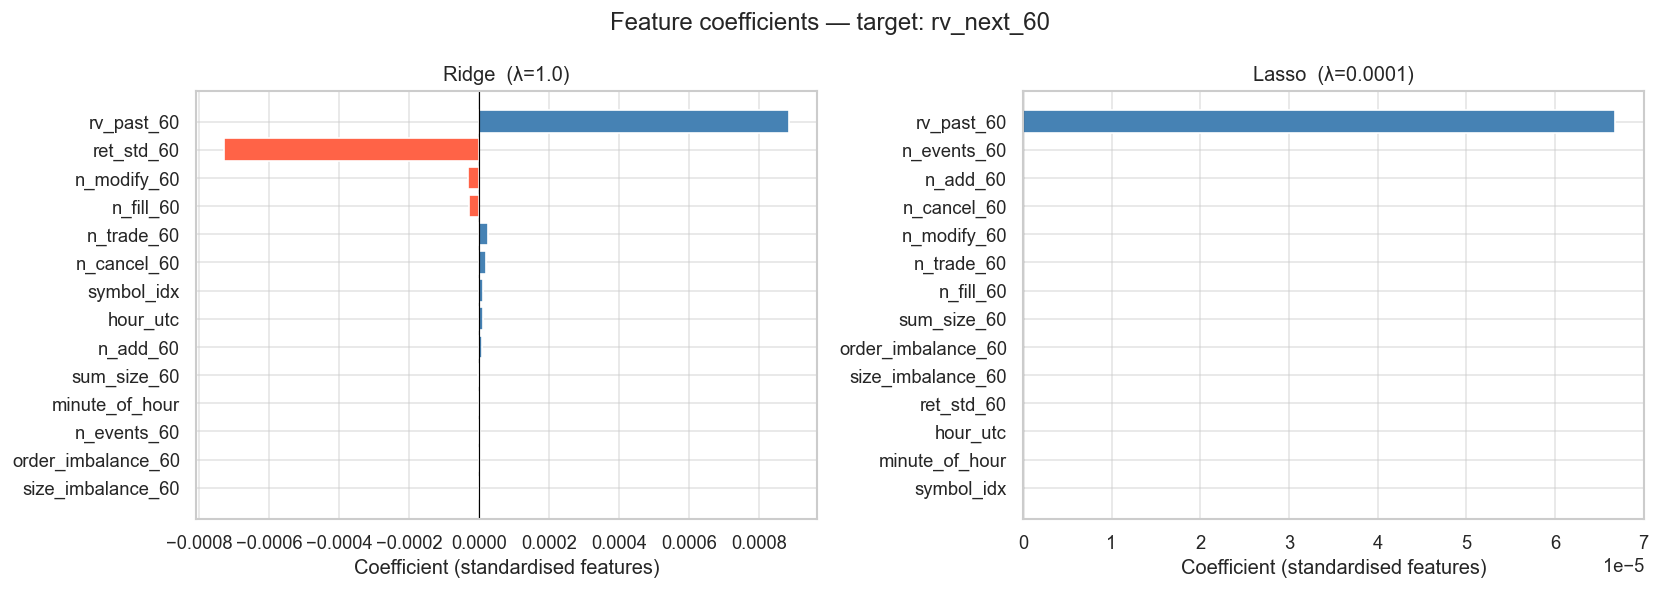


Lasso zero coefficients: ['n_events_60', 'n_add_60', 'n_cancel_60', 'n_modify_60', 'n_trade_60', 'n_fill_60', 'sum_size_60', 'order_imbalance_60', 'size_imbalance_60', 'ret_std_60', 'hour_utc', 'minute_of_hour', 'symbol_idx']

Lasso kept features:
   feature  coefficient
rv_past_60     0.000067


In [14]:
def make_coef_df(coef_arr, feature_names):
    return (pd.DataFrame({'feature': feature_names, 'coefficient': coef_arr})
              .sort_values('coefficient', key=abs, ascending=False))

ridge_coefs = make_coef_df(best_ridge[5], FEATURE_COLS)
lasso_coefs = make_coef_df(best_lasso[5], FEATURE_COLS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, coefs, title in [
    (axes[0], ridge_coefs, f'Ridge  (λ={best_ridge[0]})'),
    (axes[1], lasso_coefs, f'Lasso  (λ={best_lasso[0]})'),
]:
    colors = ['steelblue' if v >= 0 else 'tomato' for v in coefs['coefficient']]
    ax.barh(coefs['feature'], coefs['coefficient'], color=colors)
    ax.axvline(0, color='black', linewidth=0.7)
    ax.set_title(title)
    ax.set_xlabel('Coefficient (standardised features)')
    ax.invert_yaxis()

plt.suptitle(f'Feature coefficients — target: {TARGET}')
plt.tight_layout()
plt.show()

print('\nLasso zero coefficients:', lasso_coefs[lasso_coefs['coefficient'] == 0]['feature'].tolist())
print('\nLasso kept features:')
print(lasso_coefs[lasso_coefs['coefficient'] != 0][['feature','coefficient']].to_string(index=False))


## 11. Residual Analysis

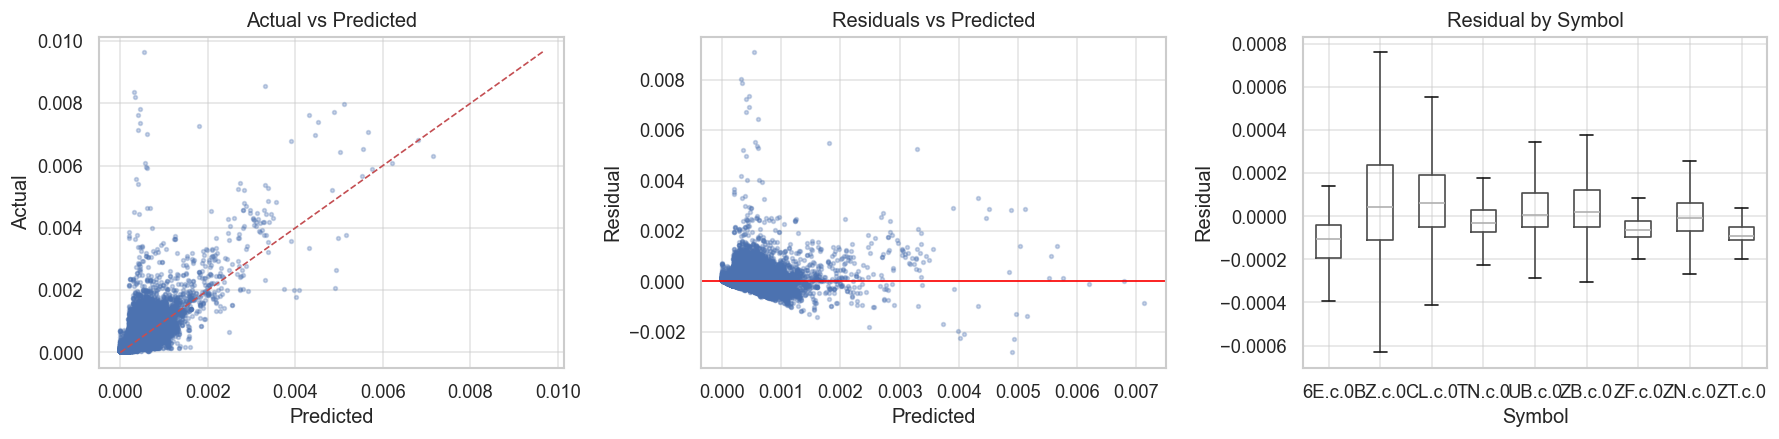

In [15]:
sample = test_pd.sample(frac=0.05, random_state=42).copy()
sample['prediction'] = np.maximum(best_ridge_model.predict(scale(sample)), 0)
sample['residual']   = sample[TARGET] - sample['prediction']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(sample['prediction'], sample[TARGET], alpha=0.3, s=5)
lim = max(sample[TARGET].max(), sample['prediction'].max())
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title('Actual vs Predicted')

axes[1].scatter(sample['prediction'], sample['residual'], alpha=0.3, s=5)
axes[1].axhline(0, color='red', linewidth=1)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs Predicted')

sample.boxplot(column='residual', by='symbol', ax=axes[2], showfliers=False)
axes[2].set_title('Residual by Symbol')
axes[2].set_xlabel('Symbol'); axes[2].set_ylabel('Residual')
plt.suptitle('')
plt.tight_layout()
plt.show()


## 12. MLflow  Log Best Models

Logs params, val/test metrics, and the fitted Spark ML pipeline artifact for each model.

In [16]:
# Best models already logged inside the sweep loops.
# Log a final summary run with both models side by side.
mlflow.set_experiment(EXPERIMENT_NAME)
with mlflow.start_run(run_name=f'BestModels_summary_{TARGET}'):
    mlflow.log_params({'best_ridge_lam': best_ridge[0], 'best_lasso_lam': best_lasso[0], 'target': TARGET})
    mlflow.log_metrics({
        'best_ridge_test_r2':   evaluate(best_ridge_model, X_test, y_test, 'ridge_test')['r2'],
        'best_lasso_test_r2':   evaluate(best_lasso_model, X_test, y_test, 'lasso_test')['r2'],
    })
print(f'Summary run logged to {MLFLOW_URI}')


  ridge_test  RMSE=0.000218  R²=0.5332  QLIKE=-7.0373
  lasso_test  RMSE=0.000269  R²=0.2916  QLIKE=-6.9768
🏃 View run BestModels_summary_rv_next_60 at: http://52.204.56.137:5000/#/experiments/530693871613804618/runs/551f4cd5fa9148c3b9bfeac5b9ddd0af
🧪 View experiment at: http://52.204.56.137:5000/#/experiments/530693871613804618
Summary run logged to http://52.204.56.137:5000


## 13. Repeat for rv_next_300

In [17]:
TARGET_300  = 'rv_next_300'
y_train_300 = train_pd[TARGET_300].values
y_val_300   = val_pd[TARGET_300].values
y_test_300  = test_pd[TARGET_300].values

ridge_300 = []
print(f'Ridge sweep — target: {TARGET_300}')
print('-' * 60)

for lam in RIDGE_PARAMS:
    with mlflow.start_run(run_name=f'Ridge_lam{lam}_{TARGET_300}'):
        mlflow.set_tag('author', 'Nandhu Sriram')
        mlflow.set_tag('model_type', 'Ridge')
        mlflow.set_tag("execution_env", "colab" if IN_COLAB else "pycharm-local")

        mlflow.log_params({'model_type': 'Ridge', 'reg_param': lam, 'target': TARGET_300})

        model = build_model('Ridge', alpha=lam)
        model.fit(X_train, y_train_300)

        m_val  = evaluate(model, X_val,  y_val_300,  'val')
        mlflow.log_metrics({'val_rmse': m_val['rmse'], 'val_r2': m_val['r2'], 'val_qlike': m_val['qlike']})

        m_test = evaluate(model, X_test, y_test_300, 'test')
        mlflow.log_metrics({'test_rmse': m_test['rmse'], 'test_r2': m_test['r2'], 'test_qlike': m_test['qlike']})

        try:
            mlflow.sklearn.log_model(model, artifact_path='model')
        except Exception as _e:
            print(f'  artifact skipped: {_e}')

        ridge_300.append((lam, m_val['rmse'], m_val['r2'], m_val['qlike'], model, model.coef_.copy()))
        print(f"  λ={lam:<6}  val R²={m_val['r2']:.4f}  test R²={m_test['r2']:.4f}")

best_ridge_300 = sorted(ridge_300, key=lambda x: x[1])[0]
print(f'\nBest Ridge λ for {TARGET_300} = {best_ridge_300[0]}')


Ridge sweep — target: rv_next_300
------------------------------------------------------------
  val    RMSE=0.000339  R²=0.5210  QLIKE=-6.3102


2026/04/11 08:38:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  test   RMSE=0.000460  R²=0.5455  QLIKE=-6.2439


2026/04/11 08:38:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  λ=0.001   val R²=0.5210  test R²=0.5455
🏃 View run Ridge_lam0.001_rv_next_300 at: http://52.204.56.137:5000/#/experiments/530693871613804618/runs/200f413b41a14b88b2e0a455c961723e
🧪 View experiment at: http://52.204.56.137:5000/#/experiments/530693871613804618
  val    RMSE=0.000339  R²=0.5210  QLIKE=-6.3102


...

  λ=0.1     val R²=0.5210  test R²=0.5455
🏃 View run Ridge_lam0.1_rv_next_300 at: http://52.204.56.137:5000/#/experiments/530693871613804618/runs/cb63ad0fd6e54898934b3d4b91fdc71d
🧪 View experiment at: http://52.204.56.137:5000/#/experiments/530693871613804618
  val    RMSE=0.000339  R²=0.5210  QLIKE=-6.3102


2026/04/11 08:38:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  test   RMSE=0.000460  R²=0.5455  QLIKE=-6.2439


2026/04/11 08:38:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  λ=1.0     val R²=0.5210  test R²=0.5455
🏃 View run Ridge_lam1.0_rv_next_300 at: http://52.204.56.137:5000/#/experiments/530693871613804618/runs/34848ab7ccf84c51897165baa8658ec3
🧪 View experiment at: http://52.204.56.137:5000/#/experiments/530693871613804618

Best Ridge λ for rv_next_300 = 1.0


## 14. Summary

In [18]:
print('=' * 60)
print('FINAL RESULTS — Test Set')
print('=' * 60)
print(results_df.pivot(index='model', columns='split').to_string())


FINAL RESULTS — Test Set
           rmse                  r2               qlike          
split      test       val      test       val      test       val
model                                                            
Lasso  0.000269  0.000202  0.291605  0.277679 -6.976818 -7.025226
Ridge  0.000218  0.000174  0.533200  0.462271 -7.037288 -7.075440


## 15. Log1p Target Transform

RV is right-skewed (heavy upper tail). Fitting on `log1p(rv)` pulls the distribution closer to Gaussian, which helps OLS. Predictions are back-transformed with `expm1` before evaluation so metrics are on the original scale.

In [19]:
# ── rv_next_60 log1p ─────────────────────────────────────────────────────
TARGET_LOG   = 'rv_next_60'
y_train_log  = np.log1p(train_pd[TARGET_LOG].values)
y_val_log    = val_pd[TARGET_LOG].values    # evaluate on original scale
y_test_log   = test_pd[TARGET_LOG].values

best_lam     = best_ridge[0]
model_log    = build_model('Ridge', alpha=best_lam)
model_log.fit(X_train, y_train_log)

def eval_log1p(model, X, y_raw, label):
    yhat = np.expm1(model.predict(X))
    yhat = np.maximum(yhat, RV_FLOOR)
    rmse  = float(np.sqrt(np.mean((y_raw - yhat) ** 2)))
    ss_res = np.sum((y_raw - yhat) ** 2)
    ss_tot = np.sum((y_raw - y_raw.mean()) ** 2)
    r2    = float(1 - ss_res / ss_tot) if ss_tot > 0 else float('nan')
    eps   = 1e-10
    qlike = float(np.mean(np.log(yhat + eps) + y_raw / (yhat + eps)))
    print(f'  {label:5s}  RMSE={rmse:.6f}  R²={r2:.4f}  QLIKE={qlike:.4f}')
    return {'rmse': rmse, 'r2': r2, 'qlike': qlike}

print('--- log1p results (rv_next_60, back-transformed) ---')
m_val_log  = eval_log1p(model_log, X_val,  y_val_log,  'val')
m_test_log = eval_log1p(model_log, X_test, y_test_log, 'test')

mlflow.set_experiment(EXPERIMENT_NAME)
with mlflow.start_run(run_name=f'Ridge_log1p_lam{best_lam}_rv_next_60'):
    mlflow.set_tag('author', 'Nandhu Sriram')
    mlflow.set_tag('model_type', 'Ridge')
    mlflow.set_tag('target_transform', 'log1p')
    mlflow.set_tag("execution_env", "colab" if IN_COLAB else "pycharm-local")
    mlflow.log_params({'model_type': 'Ridge', 'target_transform': 'log1p', 'reg_param': best_lam, 'target': 'rv_next_60'})
    mlflow.log_metrics({'val_r2': m_val_log['r2'], 'val_rmse': m_val_log['rmse'], 'val_qlike': m_val_log['qlike'],
                        'test_r2': m_test_log['r2'], 'test_rmse': m_test_log['rmse'], 'test_qlike': m_test_log['qlike']})

# ── rv_next_300 log1p ─────────────────────────────────────────────────────
y_train_300_log = np.log1p(train_pd[TARGET_300].values)
best_lam_300    = best_ridge_300[0]
model_log_300   = build_model('Ridge', alpha=best_lam_300)
model_log_300.fit(X_train, y_train_300_log)

print('--- log1p results (rv_next_300, back-transformed) ---')
m_val_log_300  = eval_log1p(model_log_300, X_val,  y_val_300,  'val')
m_test_log_300 = eval_log1p(model_log_300, X_test, y_test_300, 'test')

with mlflow.start_run(run_name=f'Ridge_log1p_lam{best_lam_300}_rv_next_300'):
    mlflow.log_params({'model_type': 'Ridge', 'target_transform': 'log1p', 'reg_param': best_lam_300, 'target': 'rv_next_300'})
    mlflow.log_metrics({'val_r2': m_val_log_300['r2'], 'val_rmse': m_val_log_300['rmse'],
                        'test_r2': m_test_log_300['r2'], 'test_rmse': m_test_log_300['rmse']})

# ── comparison tables ─────────────────────────────────────────────────────
def _m(model, X, y):
    yhat = np.maximum(model.predict(X), RV_FLOOR)
    rmse = float(np.sqrt(np.mean((y-yhat)**2)))
    r2   = float(1 - np.sum((y-yhat)**2)/np.sum((y-y.mean())**2))
    eps  = 1e-10
    return {'RMSE': f'{rmse:.6f}', 'R²': f'{r2:.4f}',
            'QLIKE': f'{float(np.mean(np.log(yhat+eps)+y/(yhat+eps))):.4f}'}

print('\n=== Test-set comparison — rv_next_60 ===')
cmp60 = pd.DataFrame([
    {'Model': f'Ridge (λ={best_ridge[0]})',      'Transform': 'none',  **_m(best_ridge_model, X_test, y_test)},
    {'Model': f'Lasso (λ={best_lasso[0]})',      'Transform': 'none',  **_m(best_lasso_model, X_test, y_test)},
    {'Model': f'Ridge log1p (λ={best_lam})',     'Transform': 'log1p', **{k: f'{v:.6f}' if k=="RMSE" else f'{v:.4f}' for k,v in
        dict(zip(['RMSE','R²','QLIKE'],[m_test_log['rmse'],m_test_log['r2'],m_test_log['qlike']])).items()}},
]).set_index('Model')
print(cmp60.to_string())

print('\n=== Test-set comparison — rv_next_300 ===')
cmp300 = pd.DataFrame([
    {'Model': f'Ridge (λ={best_ridge_300[0]})',     'Transform': 'none',  **_m(best_ridge_300[4], X_test, y_test_300)},
    {'Model': f'Ridge log1p (λ={best_lam_300})',    'Transform': 'log1p', **{k: f'{v:.6f}' if k=="RMSE" else f'{v:.4f}' for k,v in
        dict(zip(['RMSE','R²','QLIKE'],[m_test_log_300['rmse'],m_test_log_300['r2'],m_test_log_300['qlike']])).items()}},
]).set_index('Model')
print(cmp300.to_string())

spark.stop()
print('Spark session stopped.')


--- log1p results (rv_next_60, back-transformed) ---
  val    RMSE=0.000174  R²=0.4622  QLIKE=-7.0754
  test   RMSE=0.000218  R²=0.5332  QLIKE=-7.0373
🏃 View run Ridge_log1p_lam1.0_rv_next_60 at: http://52.204.56.137:5000/#/experiments/530693871613804618/runs/6ea7650cd4e54fa39cd51af9a7079f2f
🧪 View experiment at: http://52.204.56.137:5000/#/experiments/530693871613804618
--- log1p results (rv_next_300, back-transformed) ---
  val    RMSE=0.000339  R²=0.5208  QLIKE=-6.3102
  test   RMSE=0.000460  R²=0.5454  QLIKE=-6.2439
🏃 View run Ridge_log1p_lam1.0_rv_next_300 at: http://52.204.56.137:5000/#/experiments/530693871613804618/runs/20908bdd7a3a4d7a9f01d86ecf9ca5f0
🧪 View experiment at: http://52.204.56.137:5000/#/experiments/530693871613804618

=== Test-set comparison — rv_next_60 ===
                    Transform      RMSE      R²    QLIKE
Model                                                   
Ridge (λ=1.0)            none  0.000218  0.5332  -7.0373
Lasso (λ=0.0001)         none  0.0002

# Linear Regression Models for Volatility Forecasting Conclusion

Across both **Ridge** and **Lasso** regression, the results point in the same direction.
- `rv_past_60` was the dominant predictor, but the broader **MBO microstructure feature set** improved Ridge performance meaningfully.

At the **shorter 60-second horizon**, Ridge achieved solid performance.
- Ridge (λ=1.0): RMSE=0.000218, R²=0.533, QLIKE=-7.037
- Lasso (λ=0.0001): RMSE=0.000269, R²=0.292, QLIKE=-6.977
- Ridge substantially outperformed Lasso, suggesting that retaining all 13 features even with small coefficients adds predictive value.

At the **longer 300-second horizon**, Ridge held up well.
- R² slightly improved over the 60-second target, indicating that the feature set captures medium-term volatility structure effectively.

Lasso's aggressive sparsity tells a clear story:
- At λ=0.0001, Lasso zeroed out all features except `rv_past_60`, effectively reducing to a univariate model.
- The resulting R²=0.29 vs Ridge's R²=0.53 confirms the other 12 features carry real signal that Lasso discards.

The log1p target transform yielded **no improvement** (identical metrics), indicating the residuals are not heavily right-skewed enough to benefit from a Gaussian pull.

Overall takeaway:
- recent realized volatility (`rv_past_60`) is the strongest single predictor, but **microstructure features add meaningful lift** when kept via Ridge regularization
- linear models explain ~53–55% of variance at both horizons — a strong baseline before nonlinear models (XGBoost, LSTM)
- the relationship between microstructure features and volatility is likely **nonlinear**, as Lasso's feature elimination and the remaining unexplained variance both suggest
-   Linear regression serves as a strong interpretable baseline for realized volatility forecasting. Ridge regression (λ=1.0) explained ~53% of variance at the 60-second horizon and ~55% at the 300-second horizon with the slightly better performance at 5 minutes confirming that microstructure features capture trends that persist beyond a single second. Lasso's collapse to a single feature (rv_past_60) highlights that the feature relationships are likely nonlinear, and that regularization alone cannot recover them in a linear framework. The consistent QLIKE improvement of Ridge over Lasso further supports this.
- The results set a clear benchmark: any nonlinear model (XGBoost, LSTM) would likely outperform linear regression.
- Traditional time-series models like **ARIMA** or **GARCH** would likely outperform plain linear regression too. However, neither incorporates order book microstructure features, which our results show carry meaningful predictive signal beyond recent volatility alone.

---